# Ekologická Kuznetsova křivka — Analýza lesního pokryvu
## Vede ekonomický růst k odlesňování, nebo zalesňování?

---

**Co budeme zkoumat:**  
Environmental Kuznets Curve (EKC) je ekonomická teorie, která říká, že s růstem HDP na obyvatele nejprve dochází ke zhoršování životního prostředí, ale po překročení určité příjmové hranice se trend obrátí a stav se začne zlepšovat. V tomto notebooku ji aplikujeme na data o lesnatosti.

**Hypotéza:**  
Vztah mezi HDP na obyvatele a změnou plochy lesa existuje, ale není lineární.  
- Chudé země odlesňují (ekonomický tlak na půdu)  
- Bohaté země stabilizují nebo zalesňují (politická vůle, přesun ekonomiky na služby)  
- Existují výjimky v obou skupinách (kultura, politika, geografie)

**Datové zdroje:**  
| Soubor | Obsah |
|---|---|
| `forest_ekc_model.csv` | Lesnatost zemí v 1990 a 2025, změna v p.b. |
| `MAIN_Forest_GDP_joined.csv` | Lesnatost + HDP/obyv. po letech (panel data) |
| `2025_World_Bank_classification_by_Income.csv` | Klasifikace zemí dle příjmu (WB) |

## 1. Nastavení — Import knihoven

**Importujeme knihovny**, které budeme potřebovat. Každá dělá něco jiného:

| Knihovna | Zkratka | K čemu slouží |
|---|---|---|
| `pandas` | `pd` | práce s tabulkovými daty (načítání CSV, filtrování, agregace) |
| `numpy` | `np` | numerické výpočty (logaritmy, polynomy, pole čísel) |
| `matplotlib.pyplot` | `plt` | základní kreslení grafů |
| `seaborn` | `sns` | pokročilejší statistické grafy postavené nad matplotlib |
| `scipy.stats` | `stats` | statistické testy (korelace, p-hodnoty) |

> **Konvence `as pd`, `as np`...** je standardní zkratka — celý svět Pythonu ji používá stejně, takže kód je okamžitě čitelný pro každého.

In [1]:
# %matplotlib inline je tzv. "magic command" specifický pro Jupyter notebooky.
# Říká matplotlib, aby grafy vykresloval přímo do notebooku (inline),
# místo pokusu o otevření externího okna.
%matplotlib inline

import pandas as pd          # tabulková data
import numpy as np           # numerické výpočty
import matplotlib.pyplot as plt  # základní grafy
import seaborn as sns        # pokročilé statistické grafy
from scipy import stats      # statistické testy

# sns.set_theme() nastaví jednotný vizuální styl pro všechny grafy v notebooku.
# style="whitegrid" = bílé pozadí s šedou mřížkou
# font_scale=1.1  = o 10 % větší písmo než výchozí
sns.set_theme(style="whitegrid", font_scale=1.1)

# plt.rcParams je slovník globálních nastavení matplotlib.
# figure.dpi=120 zvyšuje rozlišení grafů (výchozí je 72 nebo 100).
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Načtení dat

**Načítáme tři datasety**, každý slouží jinému účelu.

Základní funkce pro načtení dat je `pd.read_csv("cesta/k/souboru.csv")`.  
Vrací objekt zvaný **DataFrame** — tabulka se sloupci (columns) a řádky (rows).

Cesty k souborům ukládáme do proměnných `DATA_DAN` a `DATA_RAW` — pokud přesuneme notebook, stačí změnit jeden řádek místo desítek.

In [2]:
# Cesty k datovým složkám — relativní od místa, kde leží tento notebook.
# ".." znamená "o složku výš", tedy z analysis_dan/ přejdeme do kořene projektu.
DATA_DAN = "../data_dan/"
DATA_RAW = "../data_raw/"

# --- Dataset 1: Změna lesnatosti zemí (1990 vs 2025) ---
# Tento soubor má standardní hlavičku — načteme ho rovnou.
df_forest = pd.read_csv(DATA_DAN + "forest_ekc_model.csv")

# df.shape vrátí dvojici (počet řádků, počet sloupců)
print("Forest dataset:", df_forest.shape)

# .head(3) zobrazí prvních 3 řádky — rychlá kontrola, zda data vypadají správně
df_forest.head(3)

Forest dataset: (211, 5)


,Country,Code,Forest_1990,Forest_2025,Forest_change
0,Afghanistan,AFG,1.85,1.85,0.00
1,Albania,ALB,28.79,34.34,5.55
2,Algeria,DZA,0.72,0.71,-0.01


In [3]:
# --- Dataset 2: Panel data — lesnatost + HDP po letech ---
# "Panel data" = stejné země sledované opakovaně v různých letech.
# Každý řádek je jedna země v jednom roce.
df_panel = pd.read_csv(DATA_DAN + "MAIN_Forest_GDP_joined.csv")

print("Panel dataset:", df_panel.shape)
df_panel.head(3)

Panel dataset: (7970, 6)


,Entity,Code,Year,Share of land covered by forest,Share of land covered by forest (Annotations),GDP per capita (current US$)
0,Afghanistan,AFG,1990,1.854315,NaN,NaN
1,Afghanistan,AFG,1991,1.854315,NaN,NaN
2,Afghanistan,AFG,1992,1.854315,NaN,NaN


In [4]:
# --- Dataset 3: Klasifikace zemí dle příjmu (World Bank) ---
# Tento CSV soubor má NETYPICKÉ záhlaví — první 2 řádky jsou popis souboru,
# ne sloupce dat. Parametr skiprows=2 tyto řádky přeskočí.
#
# Bez skiprows=2 by pandas špatně přečetl sloupce a data by nefungovala!
df_income = pd.read_csv(
    DATA_RAW + "2025_World_Bank_classification_by_Income.csv",
    skiprows=2
)

print("Income classification:", df_income.shape)
df_income.head(3)

Income classification: (221, 5)


,Country,Code,Region,Income group,Classification
0,Afghanistan,AFG,South Asia,Low income,LIC
1,Albania,ALB,Europe & Central Asia,Upper middle income,UMIC
2,Algeria,DZA,Middle East & North Africa,Upper middle income,UMIC


## 3. Průzkum dat (EDA)

**Exploratory Data Analysis (EDA)** — před každou analýzou si zodpovíme:
- Jaké sloupce data mají a jakého jsou datového typu?
- Kolik hodnot chybí (`NaN`)?
- Jaké jsou základní statistiky (průměr, min, max)?

Přeskočit EDA je jako řídit auto se zavázanýma očima — data mohou obsahovat překvapení, která zkazí celou analýzu.

In [5]:
print("=== FOREST DATASET ===")

# .dtypes zobrazí datový typ každého sloupce:
# object  = text (string)
# float64 = desetinné číslo
# int64   = celé číslo
print("Data types:")
print(df_forest.dtypes)

# .isnull() vrátí True/False tabulku — True = chybějící hodnota (NaN)
# .sum() sečte True hodnoty (True = 1, False = 0) — výsledek = počet chybějících
print("\nMissing values per column:")
print(df_forest.isnull().sum())

# .describe() automaticky spočítá: počet, průměr, std, min, kvartily, max
# Funguje pouze pro číselné sloupce.
print("\nBasic statistics:")
df_forest.describe()

=== FOREST DATASET ===
Data types:
Country              str
Code                 str
Forest_1990      float64
Forest_2025      float64
Forest_change    float64
dtype: object

Missing values per column:
Country           0
Code             10
Forest_1990       0
Forest_2025       0
Forest_change     0
dtype: int64

Basic statistics:


,Forest_1990,Forest_2025,Forest_change
count,211.000000,211.000000,211.000000
mean,34.183602,32.974882,-1.208720
std,25.779214,24.392955,7.043896
min,0.000000,0.000000,-34.110000
25%,11.620000,11.820000,-2.865000
50%,29.910000,32.990000,0.000000
75%,53.460000,51.500000,1.695000
max,96.230000,93.360000,17.280000


In [6]:
print("=== PANEL DATASET ===")

# .unique() vrátí seznam unikátních hodnot v daném sloupci
# sorted() hodnoty seřadí od nejmenší po největší
print("Years available:", sorted(df_panel["Year"].unique()))

# .nunique() vrátí POČET unikátních hodnot (ne jejich seznam)
print("Number of countries:", df_panel["Entity"].nunique())

# Chybějící HDP hodnoty — důležité pro plánování mergování
print("Missing GDP values:", df_panel["GDP per capita (current US$)"].isnull().sum())

=== PANEL DATASET ===
Years available: [np.int64(1000), np.int64(1050), np.int64(1067), np.int64(1086), np.int64(1100), np.int64(1125), np.int64(1150), np.int64(1185), np.int64(1200), np.int64(1229), np.int64(1250), np.int64(1251), np.int64(1286), np.int64(1300), np.int64(1329), np.int64(1350), np.int64(1383), np.int64(1400), np.int64(1412), np.int64(1436), np.int64(1450), np.int64(1480), np.int64(1500), np.int64(1531), np.int64(1550), np.int64(1600), np.int64(1614), np.int64(1630), np.int64(1650), np.int64(1660), np.int64(1688), np.int64(1700), np.int64(1741), np.int64(1750), np.int64(1800), np.int64(1814), np.int64(1841), np.int64(1850), np.int64(1870), np.int64(1871), np.int64(1874), np.int64(1878), np.int64(1881), np.int64(1887), np.int64(1889), np.int64(1891), np.int64(1892), np.int64(1895), np.int64(1900), np.int64(1903), np.int64(1904), np.int64(1907), np.int64(1910), np.int64(1911), np.int64(1919), np.int64(1920), np.int64(1926), np.int64(1930), np.int64(1931), np.int64(1938), 

In [7]:
print("=== INCOME GROUPS ===")

# .value_counts() spočítá, kolikrát se každá hodnota v sloupci vyskytuje.
# Výsledek je seřazen od nejčastější po nejméně častou.
print(df_income["Income group"].value_counts())

=== INCOME GROUPS ===
Income group
High income            86
Upper middle income    55
Lower middle income    51
Low income             26
Name: count, dtype: int64


## 4. Příprava dat — Spojení datsetů

**Cíl:** pro každou zemi mít v jedné tabulce:
1. Změnu lesnatosti 1990–2025 (z `forest_ekc_model.csv`)
2. Průměrné HDP na obyvatele (vypočítáme z panel dat)
3. Příjmovou skupinu a region (z klasifikace WB)

**Klíčový koncept — merge (spojení tabulek):**  
Podobně jako JOIN v SQL. Spojujeme tabulky přes společný sloupec — kód země (`Code`).

```
df_forest  +  df_gdp_avg  +  df_income_clean
   Code            Code            Code
   ----            ----            ----
   CZE             CZE             CZE
   DEU    →        DEU    →        DEU    →  výsledná tabulka
   BRA             BRA             BRA
```

In [8]:
# --- Krok 1: Průměrné HDP na obyvatele za všechna dostupná léta ---
#
# Z panel dat (kde každý řádek = jedna země v jednom roce) chceme
# jedno číslo na zemi — průměr přes všechna léta.
#
# Postup (řetězení metod, tzv. "method chaining"):
#
# 1) .dropna(subset=[...]) — odstraní řádky, kde HDP chybí (NaN)
#    Bez tohoto kroku by průměr zahrnoval NaN a vrátil by NaN.
#
# 2) .groupby("Code") — rozdělí tabulku do skupin podle kódu země.
#    Každá skupina = všechny řádky jedné země.
#
# 3) ["GDP per capita (current US$)"] — vybereme pouze tento sloupec
#
# 4) .mean() — spočítá průměr v každé skupině
#
# 5) .reset_index() — přemění index (Code) zpět na normální sloupec
#
# 6) .rename(columns={...}) — přejmenuje sloupec na kratší název

df_gdp_avg = (
    df_panel
    .dropna(subset=["GDP per capita (current US$)"])
    .groupby("Code")["GDP per capita (current US$)"]
    .mean()
    .reset_index()
    .rename(columns={"GDP per capita (current US$)": "GDP_avg"})
)

print(f"Countries with GDP data: {len(df_gdp_avg)}")
df_gdp_avg.head(3)

Countries with GDP data: 208


,Code,GDP_avg
0,ABW,23517.494200
1,AFG,415.494946
2,AGO,2301.953290


In [9]:
# --- Krok 2: Zjednodušení tabulky s příjmovými skupinami ---
#
# Z df_income potřebujeme jen 3 sloupce. Výběr více sloupců najednou:
# df[["sloupec1", "sloupec2"]] — dvojité hranaté závorky!
# .dropna(subset=["Code"]) — odstraní řádky bez kódu země

df_income_clean = df_income[["Code", "Region", "Income group"]].dropna(subset=["Code"])

# --- Krok 3: Merge všech tří datasetů ---
#
# .merge(pravá_tabulka, on="společný sloupec", how="typ joinu")
#
# how="inner" = zachová jen země, které existují v OBOU tabulkách
#   → pokud nemáme HDP pro danou zemi, vypadne z analýzy
# how="left"  = zachová všechny řádky z levé tabulky
#   → pokud nemáme income group, dostane NaN (to vyřešíme v kroku 4)

df = (
    df_forest
    .merge(df_gdp_avg,      on="Code", how="inner")  # pouze země s HDP daty
    .merge(df_income_clean, on="Code", how="left")   # přidáme region + income group
)

# --- Krok 4: Odstranit řádky s chybějícími klíčovými hodnotami ---
# dropna(subset=[...]) odstraní řádky, kde ALESPOŇ JEDEN z těchto sloupců je NaN
df = df.dropna(subset=["Forest_change", "GDP_avg", "Income group"])

print(f"Final dataset: {len(df)} countries")
df.head(5)

Final dataset: 199 countries


,Country,Code,Forest_1990,Forest_2025,Forest_change,GDP_avg,Region,Income group
0,Afghanistan,AFG,1.85,1.85,0.00,415.494946,South Asia,Low income
1,Albania,ALB,28.79,34.34,5.55,3520.932338,Europe & Central Asia,Upper middle income
2,Algeria,DZA,0.72,0.71,-0.01,3545.598543,Middle East & North Africa,Upper middle income
3,American Samoa,ASM,90.35,79.25,-11.10,11575.375660,East Asia & Pacific,High income
4,Andorra,AND,37.64,38.77,1.13,34124.770096,Europe & Central Asia,High income


In [10]:
# --- Krok 5: Logaritmická transformace HDP ---
#
# Proč logaritmus?
# HDP na obyvatele má obrovský rozsah: od ~$300 (nejchudší země) do ~$130 000 (nejbohatší).
# Na lineární ose by 90 % bodů bylo nalepeno vlevo a pár boháčů vpravo.
# Logaritmus tento rozsah "zploští" — rozdíl $300 vs $3 000 je stejně velký
# jako $30 000 vs $300 000 (oba jsou 10x nárůst).
#
# np.log() = přirozený logaritmus (základ e ≈ 2.718)
# np.log10() by byl logaritmus základ 10 — fungoval by taky, jen jinak skalovaný

df["log_GDP"] = np.log(df["GDP_avg"])

print("Income group distribution in final dataset:")
print(df["Income group"].value_counts())

Income group distribution in final dataset:
Income group
High income            75
Upper middle income    52
Lower middle income    47
Low income             25
Name: count, dtype: int64


## 5. Popisná statistika dle příjmové skupiny

**Základní přehled:** jak se liší průměrná změna lesnatosti mezi příjmovými skupinami?  
Tohle je první test naší hypotézy — bez jakékoliv regrese, jen čísla.

In [11]:
# Definujeme pořadí příjmových skupin od nejchudší po nejbohatší.
# Toto pořadí použijeme konzistentně ve všech grafech a tabulkách.
income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]

# Agregace pomocí groupby + agg:
# .groupby("Income group") — rozdělí DataFrame do 4 skupin
# ["Forest_change"]        — pracujeme jen s tímto sloupcem
# .agg(["mean", "median", "std", "count"]) — spočítá VÍCE statistik najednou
#
# .reindex(income_order) — seřadí řádky do našeho vlastního pořadí
#   (bez toho by byly seřazeny abecedně)
# .round(2) — zaokrouhlí na 2 desetinná místa

summary = (
    df.groupby("Income group")["Forest_change"]
    .agg(["mean", "median", "std", "count"])
    .reindex(income_order)
    .round(2)
)

# Přejmenujeme sloupce na čitelnější názvy
summary.columns = ["Mean change (p.b.)", "Median change (p.b.)", "Std dev", "N countries"]

print(summary)
print("\n💡 Positive = gained forest area | Negative = lost forest area")

                     Mean change (p.b.)  Median change (p.b.)  Std dev  \
Income group                                                             
Low income                        -5.55                 -2.88     7.00   
Lower middle income               -3.91                 -1.14     8.63   
Upper middle income               -0.61                  0.00     7.41   
High income                        1.38                  0.79     4.29   

                     N countries  
Income group                      
Low income                    25  
Lower middle income           47  
Upper middle income           52  
High income                   75  

💡 Positive = gained forest area | Negative = lost forest area


## 6. Box plot — Změna lesa dle příjmové skupiny

**Box plot** (krabicový graf) ukazuje rozložení hodnot v každé skupině:

```
      │
  ────┤  ← maximální hodnota (bez outlierů)
  │  │
  │  │  ← 75. percentil (Q3)
  ├──┤
  │==│  ← medián (50. percentil)
  ├──┤
  │  │  ← 25. percentil (Q1)
  │  │
  ────┤  ← minimální hodnota (bez outlierů)
  ●   ← outlier (hodnota daleko od středu)
```

> **Co hledáme:** Posouvá se medián (střední čára) směrem nahoru s rostoucím bohatstvím?

C:\Users\I343830\AppData\Local\Temp\ipykernel_24184\2346514914.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in income_order])


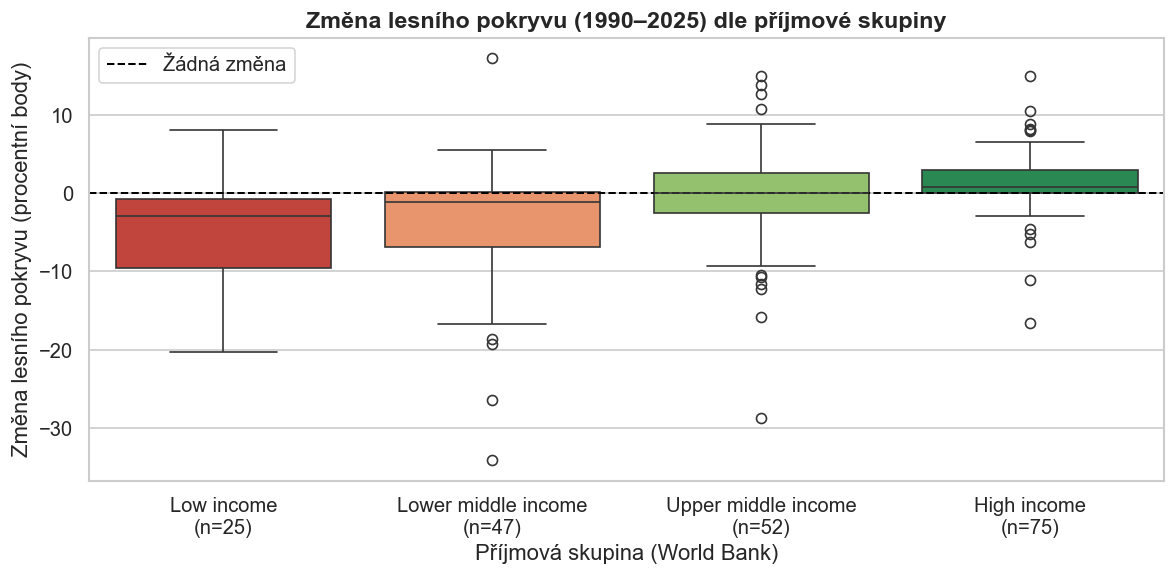

In [12]:
# Definujeme barevnou paletu — každá income skupina má svou barvu.
# Klíč slovníku = název skupiny, hodnota = hex kód barvy.
color_map = {
    "Low income":           "#d73027",  # červená = odlesňování
    "Lower middle income":  "#fc8d59",  # oranžová
    "Upper middle income":  "#91cf60",  # světle zelená
    "High income":          "#1a9850"   # tmavě zelená = zalesňování
}

# --- Vytvoření grafu ---
# plt.subplots() vytvoří "plátno" (fig) a "osy" (ax).
# figsize=(šířka, výška) v palcích
fig, ax = plt.subplots(figsize=(10, 5))

# sns.boxplot() nakreslí box plot.
# data=df       — zdrojový DataFrame
# x=            — sloupec pro osu X (kategorie)
# y=            — sloupec pro osu Y (hodnoty)
# order=        — pořadí kategorií na ose X
# hue=          — barva podle stejného sloupce jako x (moderní seaborn syntax)
# palette=      — slovník barva → hodnota
# legend=False  — skryjeme duplikátní legendu (barvy jsou stejné jako x-osa)
sns.boxplot(
    data=df,
    x="Income group", y="Forest_change",
    order=income_order,
    hue="Income group", hue_order=income_order,
    palette=color_map,
    legend=False,
    ax=ax
)

# ax.axhline() nakreslí vodorovnou čáru (a = axis, h = horizontal)
# y=0 = nulová změna; slouží jako vizuální reference
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="Žádná změna")

# Nadpis a popis os
ax.set_title("Změna lesního pokryvu (1990–2025) dle příjmové skupiny", fontsize=14, fontweight="bold")
ax.set_xlabel("Příjmová skupina (World Bank)")
ax.set_ylabel("Změna lesního pokryvu (procentní body)")
ax.legend()

# Přidáme počet zemí do popisku na ose X
counts = df["Income group"].value_counts().reindex(income_order)
ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in income_order])

# plt.tight_layout() automaticky upraví mezery, aby se popisky nepřekrývaly
plt.tight_layout()

# Uložíme graf jako PNG soubor do aktuální složky
plt.savefig("plot_01_boxplot_income.png", dpi=150)
plt.show()

## 7. EKC bodový graf — Hlavní vizualizace

**Toto je hlavní vizualizace.** Scatter plot (bodový graf) zobrazí každou zemi jako jeden bod:

- **Osa X:** logaritmus průměrného HDP na obyvatele (bohatší země = vpravo)  
- **Osa Y:** změna lesnatosti 1990–2025 v procentních bodech  
- **Barva bodu:** příjmová skupina WB  
- **Popisek:** kód země u extrémních outlierů  

> **Jak číst EKC tvar:** Pokud hypotéza platí, body budou tvořit písmeno **U** — nejprve klesají (odlesňování), pak rostou (zalesňování). Pokud trend vůbec neexistuje, body budou rozptýleny náhodně.

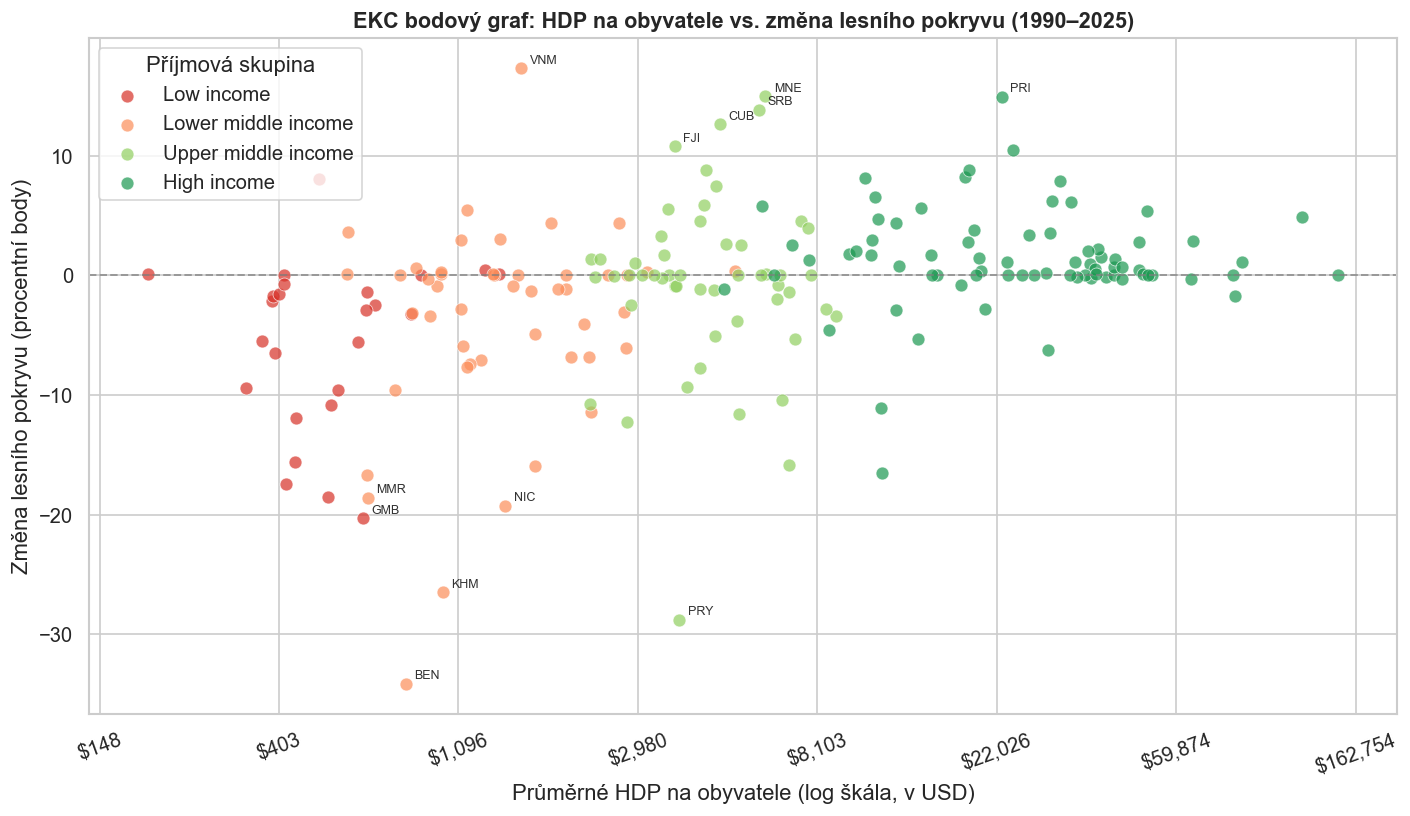

In [13]:
# Definujeme pozice značek na ose X (v log škále).
# Tyto hodnoty pak přepočítáme zpět na skutečné USD pro popisky.
log_ticks = [5, 6, 7, 8, 9, 10, 11, 12]
# Příklady: np.exp(5) ≈ $148, np.exp(8) ≈ $2 981, np.exp(11) ≈ $59 874

fig, ax = plt.subplots(figsize=(12, 7))

# Kreslíme každou income skupinu zvlášť — tak můžeme nastavit barvu a label
for group in income_order:
    # Filtrování DataFrame: df[podmínka] vrátí pouze řádky splňující podmínku
    subset = df[df["Income group"] == group]

    # ax.scatter() nakreslí bodový graf
    # alpha=0.7     — průhlednost bodů (0 = neviditelný, 1 = plný)
    # edgecolors    — barva okraje bodu (bílá = body se lépe odliší)
    # linewidths    — tloušťka okraje bodu
    # s=60          — velikost bodu (size)
    ax.scatter(
        subset["log_GDP"],
        subset["Forest_change"],
        c=color_map[group],
        label=group,
        alpha=0.7,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )

# Nulová referenční čára
ax.axhline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)

# --- Anotace extrémních outlierů ---
# Hledáme země, jejichž Forest_change je v dolním nebo horním 3 % hodnot.
# .quantile(0.03) = 3. percentil (3 % hodnot je pod touto hranicí)
outliers = df[
    (df["Forest_change"] < df["Forest_change"].quantile(0.03)) |
    (df["Forest_change"] > df["Forest_change"].quantile(0.97))
]

# Iterujeme přes řádky outlier DataFrame
# iterrows() vrací dvojice (index, Series) — _ znamená "index ignorujeme"
for _, row in outliers.iterrows():
    ax.annotate(
        row["Code"],                         # text popisku
        xy=(row["log_GDP"], row["Forest_change"]),  # souřadnice bodu
        xytext=(5, 3),                        # posun textu v pixelech
        textcoords="offset points",           # xytext je relativní posun
        fontsize=7.5,
        color="#333333"
    )

# --- Přepočet osy X z log hodnot na skutečné USD ---
# np.exp() je inverzní funkce k np.log() — převede log hodnotu zpět na USD
ax.set_xticks(log_ticks)
ax.set_xticklabels([f"${int(np.exp(t)):,}" for t in log_ticks], rotation=20)
# f"${int(np.exp(t)):,}" — formátovací řetězec:
#   $       = dolar sign
#   int()   = zaokrouhlí na celé číslo
#   :,      = přidá oddělovač tisíců (1000 → 1,000)

ax.set_title("EKC bodový graf: HDP na obyvatele vs. změna lesního pokryvu (1990–2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Průměrné HDP na obyvatele (log škála, v USD)")
ax.set_ylabel("Změna lesního pokryvu (procentní body)")
ax.legend(title="Příjmová skupina", loc="upper left")

plt.tight_layout()
plt.savefig("plot_02_ekc_scatter.png", dpi=150)
plt.show()

## 8. Regresní analýza

**Regrese kvantifikuje vztah** — místo dojmu z grafu dostaneme čísla.

Porovnáme dvě varianty:  
1. **Lineární regrese** — přímka: `Forest_change = a + b × log(GDP)`  
2. **Kvadratická regrese (EKC tvar)** — parabola: `Forest_change = a + b × log(GDP) + c × log(GDP)²`

**Jak hodnotit výsledky:**
- **R²** (koeficient determinace): podíl rozptylu dat vysvětlený modelem. R²=0.15 znamená, že model vysvětluje 15 % variability — v sociálních vědách je to normální, data jsou velmi "hlučná".
- **p-hodnota**: pravděpodobnost, že by výsledek nastal náhodně. p < 0.05 = statisticky signifikantní výsledek.

In [14]:
# Připravíme numpy pole (arrays) — scipy a numpy pracují s arrays, ne s pandas Series
x = df["log_GDP"].values        # proměnná X: log HDP
y = df["Forest_change"].values  # proměnná Y: změna lesnatosti

# --- Lineární regrese pomocí scipy.stats.linregress ---
# Funkce vrátí 5 hodnot najednou — rozbalíme je do pojmenovaných proměnných:
# slope     = směrnice přímky (b) — o kolik se Y změní při zvýšení X o 1
# intercept = průsečík s Y osou (a)
# r_lin     = Pearsonův korelační koeficient (-1 až +1)
# p_lin     = p-hodnota (je vztah statisticky signifikantní?)
# se        = standard error (přesnost odhadu slope) — tady ho nepoužijeme
slope, intercept, r_lin, p_lin, se = stats.linregress(x, y)

# R² = korelační koeficient na druhou
r2_lin = r_lin ** 2

print("=== Linear Regression ===")
print(f"  Slope:       {slope:.4f}")
print(f"  Intercept:   {intercept:.4f}")
print(f"  R²:          {r2_lin:.4f}")
print(f"  p-value:     {p_lin:.4f}")
# Podmíněný výraz (ternary operator): hodnota_pokud_true if podmínka else hodnota_pokud_false
print(f"  Significant: {'Yes' if p_lin < 0.05 else 'No'} (threshold: p < 0.05)")

=== Linear Regression ===
  Slope:       1.7027
  Intercept:   -15.7376
  R²:          0.1312
  p-value:     0.0000
  Significant: Yes (threshold: p < 0.05)


In [15]:
# --- Kvadratická regrese pomocí numpy.polyfit ---
#
# np.polyfit(x, y, deg) fituje polynom stupně deg na data.
# deg=2 = kvadratický polynom: c*x² + b*x + a
# Vrátí koeficienty od NEJVYŠŠÍHO stupně: [c, b, a]
coeffs = np.polyfit(x, y, deg=2)

# np.poly1d() z koeficientů vytvoří funkci, kterou lze zavolat: poly_fn(x)
# Umožňuje snadno spočítat y pro libovolné x bez ruční implementace
poly_fn = np.poly1d(coeffs)

# Manuální výpočet R² pro polynomiální regresi:
# SS_res = suma čtverců reziduálů (rozdíl skutečných a predikovaných hodnot)
# SS_tot = suma čtverců od průměru (celková variabilita dat)
# R² = 1 - SS_res/SS_tot
y_pred_quad = poly_fn(x)                          # predikované hodnoty
ss_res = np.sum((y - y_pred_quad) ** 2)            # suma čtverců reziduálů
ss_tot = np.sum((y - y.mean()) ** 2)               # celková variabilita
r2_quad = 1 - ss_res / ss_tot                      # koeficient determinace

print("=== Quadratic Regression ===")
print(f"  Coefficient (log_GDP²): {coeffs[0]:.4f}  ← pokud kladný, křivka je U-tvar")
print(f"  Coefficient (log_GDP):  {coeffs[1]:.4f}")
print(f"  Intercept:              {coeffs[2]:.4f}")
print(f"  R²:                     {r2_quad:.4f}")
print(f"\n📊 Improvement from linear to quadratic: +{(r2_quad - r2_lin):.4f} R²")

=== Quadratic Regression ===
  Coefficient (log_GDP²): -0.3607  ← pokud kladný, křivka je U-tvar
  Coefficient (log_GDP):  7.8796
  Intercept:              -41.3555
  R²:                     0.1453

📊 Improvement from linear to quadratic: +0.0140 R²


## 9. Graf regresních křivek

**Vizualizujeme obě regresní křivky** přes scatter plot — vidíme, která lépe zachycuje trend v datech.

> **Tip:** Pokud jsou R² hodnoty obou modelů podobné, lineární model je lepší volba — je jednodušší a srozumitelnější. Kvadratický model dává smysl jen tehdy, pokud výrazně zlepší fit.

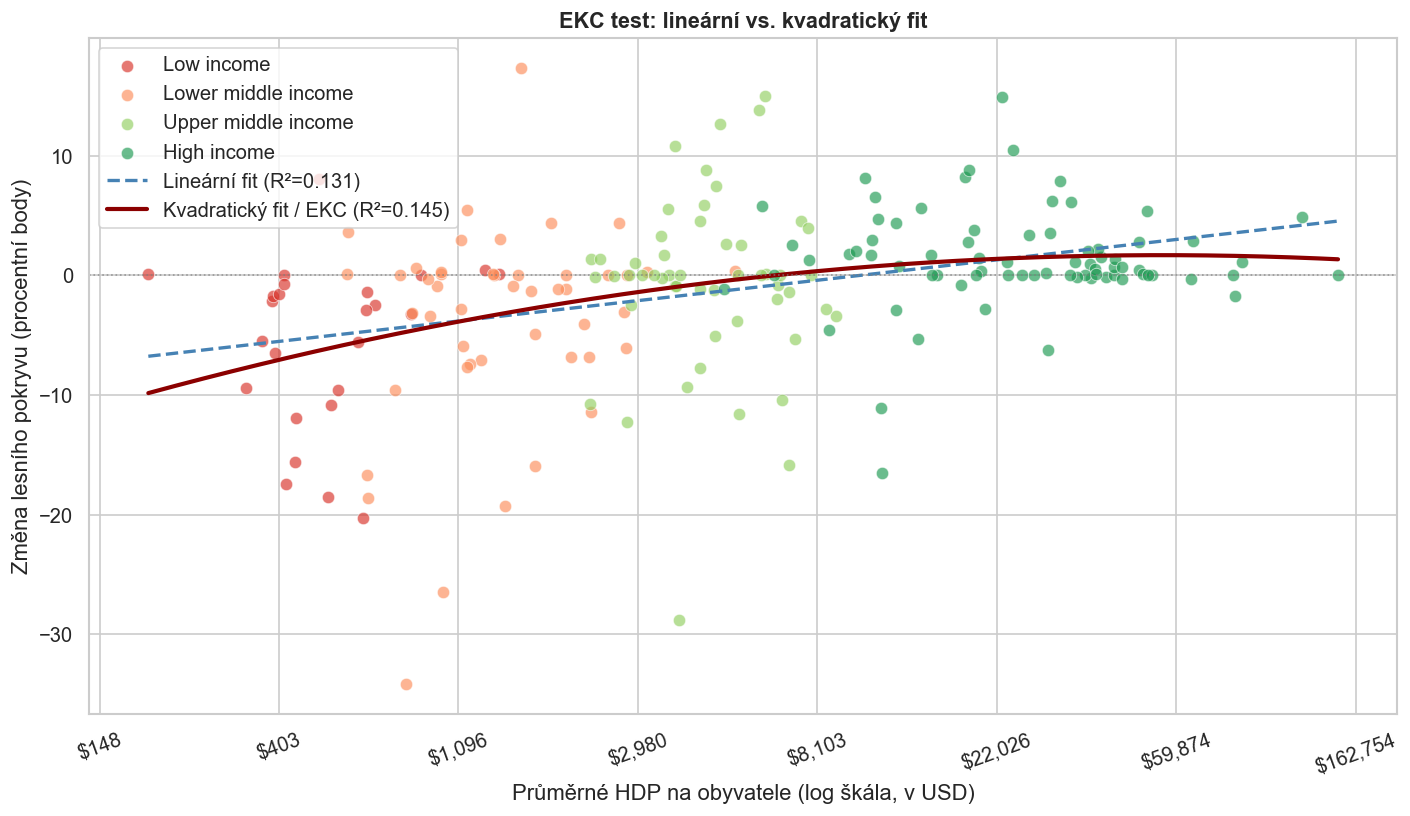

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter body — stejný kód jako v sekci 7
for group in income_order:
    subset = df[df["Income group"] == group]
    ax.scatter(subset["log_GDP"], subset["Forest_change"],
               c=color_map[group], label=group,
               alpha=0.65, edgecolors="white", linewidths=0.5, s=55)

# Vytvoříme 300 rovnoměrně rozmístěných bodů od min do max X.
# To zajistí hladkou křivku — kdybychom kreslili jen přes 199 datových bodů,
# křivka by mohla vypadat "zubatě" v místech bez dat.
x_line = np.linspace(x.min(), x.max(), 300)

# Lineární fit — rovnice přímky: y = intercept + slope * x
ax.plot(x_line, intercept + slope * x_line,
        color="steelblue", linewidth=2, linestyle="--",
        label=f"Lineární fit (R²={r2_lin:.3f})")

# Kvadratický fit — poly_fn() vypočítá hodnoty z koeficientů z np.polyfit
ax.plot(x_line, poly_fn(x_line),
        color="darkred", linewidth=2.5,
        label=f"Kvadratický fit / EKC (R²={r2_quad:.3f})")

ax.axhline(0, color="gray", linewidth=1, linestyle=":", alpha=0.7)

ax.set_xticks(log_ticks)
ax.set_xticklabels([f"${int(np.exp(t)):,}" for t in log_ticks], rotation=20)
ax.set_title("EKC test: lineární vs. kvadratický fit", fontsize=13, fontweight="bold")
ax.set_xlabel("Průměrné HDP na obyvatele (log škála, v USD)")
ax.set_ylabel("Změna lesního pokryvu (procentní body)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("plot_03_regression.png", dpi=150)
plt.show()

## 10. Časové řady zemí — pohled na panel data

**Přibližujeme se na úroveň jednotlivých zemí.** Panel data z `MAIN_Forest_GDP_joined.csv` nám umožňují sledovat, jak se lesnatost vyvíjela v čase.

Vybereme reprezentativní skupinu zemí napříč příjmovými skupinami — hledáme odlišné trajektorie.

In [17]:
# Seznam zemí pro time-series analýzu.
# Vybrali jsme zástupce různých příjmových skupin a různých trajektorií.
# Změň tento seznam a prozkoumej jiné země!
selected_countries = [
    "Brazil",     # Upper middle — velká odlesnění (Amazonie)
    "China",      # Upper middle — masivní státní program zalesňování
    "Germany",    # High income — stabilní, mírný nárůst
    "Nigeria",    # Lower middle — silný tlak na odlesnění
    "India",      # Lower middle — smíšené signály, zalesňovací programy
    "Uruguay",    # High income (latam) — rychlé zalesňování plantážemi
    "Ethiopia",   # Low income — rekordní kampaň sázení stromů
]

# Filtrujeme panel data pouze na vybrané země.
# .isin([...]) vrátí True pro řádky, kde je hodnota v daném seznamu.
# Je to ekvivalent: kde Entity == "Brazil" NEBO == "China" NEBO == ... 
df_ts = df_panel[
    df_panel["Entity"].isin(selected_countries)
].dropna(subset=["Share of land covered by forest"])  # odstraníme roky bez dat

print("Countries found:", df_ts["Entity"].unique().tolist())
print("Years covered:", df_ts["Year"].min(), "–", df_ts["Year"].max())

Countries found: ['Brazil', 'China', 'Ethiopia', 'Germany', 'India', 'Nigeria', 'Uruguay']
Years covered: 1000 – 2025


KeyError: 'Rok'

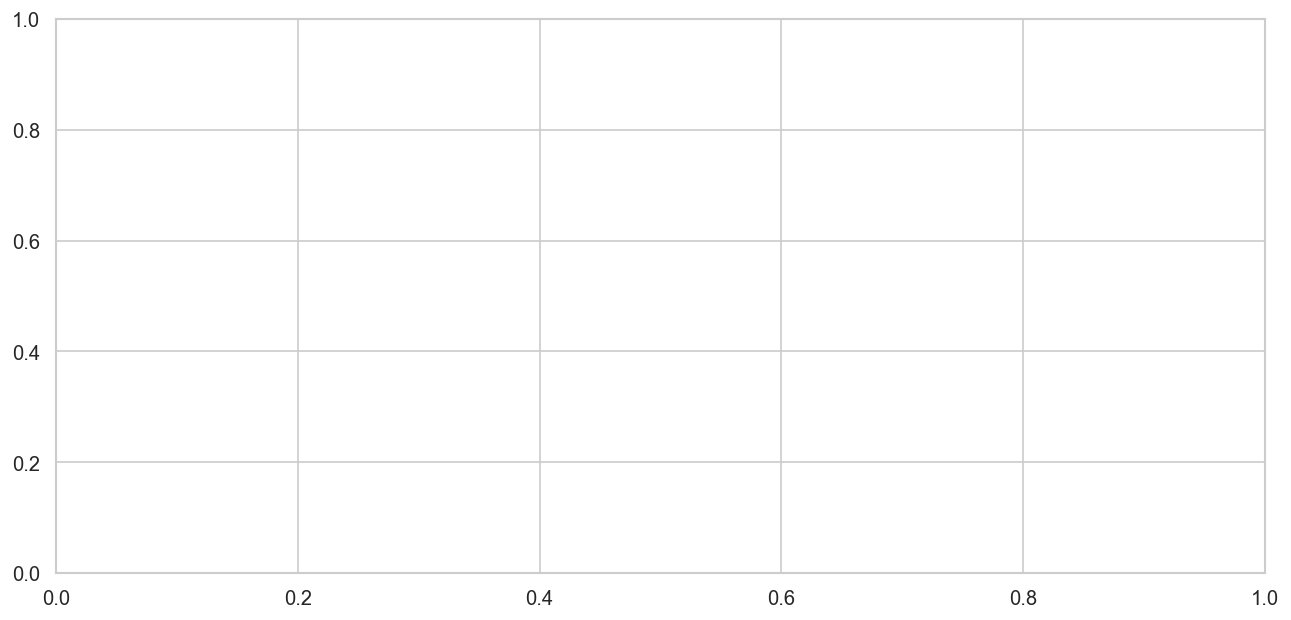

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

# Kreslíme každou zemi jako samostatnou čáru.
# matplotlib automaticky přiřadí různé barvy.
for country in selected_countries:
    # Filtr na jednu zemi + seřazení podle roku (pro správné propojení čar)
    country_data = df_ts[df_ts["Entity"] == country].sort_values("Rok")

    # Kontrola, že pro zemi existují data (isin() mohl nenajít shodu)
    if len(country_data) > 0:
        ax.plot(
            country_data["Rok"],
            country_data["Share of land covered by forest"],
            marker="o",     # tvar značky na každém datovém bodu
            markersize=3,   # velikost značky
            linewidth=1.8,  # tloušťka čáry
            label=country   # text v legendě
        )

ax.set_title("Vývoj lesního pokryvu v čase — vybrané země", fontsize=13, fontweight="bold")
ax.set_xlabel("Rok")
ax.set_ylabel("Lesní pokryv (% rozlohy)")

# Legendu umístíme mimo graf (bbox_to_anchor) — jinak by překrývala data
# loc="center left" = levý okraj legendy; bbox_to_anchor=(1, 0.5) = vpravo od grafu
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig("plot_04_timeseries.png", dpi=150)
plt.show()

## 11. Regionální srovnání — průměrná změna lesa

**Pohled přes regiony** doplní kontinent/geografický kontext, který příjmové skupiny nezachycují.  
Horizontální bar chart (sloupcový graf) je vhodný, pokud máme dlouhé popisky na ose Y.

In [ ]:
# Průměrná změna lesa a počet zemí dle regionu
region_summary = (
    df.groupby("Region")["Forest_change"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Avg Forest Change", "count": "N countries"})
    .sort_values("Avg Forest Change")  # seřadíme od nejvíce záporného po nejvíce kladné
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, 5))

# Dynamická barva: červená pro záporné hodnoty, zelená pro kladné
# List comprehension: [výraz for proměnná in iterable if podmínka]
colors = ["#d73027" if v < 0 else "#1a9850" for v in region_summary["Avg Forest Change"]]

# ax.barh() = horizontální bar chart (h = horizontal)
# ax.bar()  = vertikální bar chart
bars = ax.barh(
    region_summary.index,            # popisky na ose Y (názvy regionů)
    region_summary["Avg Forest Change"],  # délky sloupců (hodnoty)
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Přidáme číselný popisek ke každému sloupci
# zip() spojí dva iterovatelné objekty do dvojic: (bar, value)
for bar, val in zip(bars, region_summary["Avg Forest Change"]):
    ax.text(
        val + (0.05 if val >= 0 else -0.05),     # X pozice textu (těsně za koncem sloupce)
        bar.get_y() + bar.get_height() / 2,      # Y pozice textu (střed sloupce)
        f"{val:+.2f}",                           # text: +1.23 nebo -0.45 (+ vždy zobrazí znaménko)
        va="center",
        ha="left" if val >= 0 else "right",      # zarovnání textu
        fontsize=9
    )

# Svislá čára na 0 — vizuální reference pro "žádná změna"
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Průměrná změna lesního pokryvu dle regionu (1990–2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Změna lesního pokryvu (procentní body)")

plt.tight_layout()
plt.savefig("plot_05_regional.png", dpi=150)
plt.show()

## 12. Analýza výjimek — země vybočující z trendu

**Výjimky jsou stejně zajímavé jako pravidlo.** Hledáme:
- Bohaté země, které přesto odlesňují → jaké jsou důvody?
- Chudé země, které zalesňují navzdory ekonomickému tlaku → co je jinak?

Tyto výjimky jsou důkazem, že HDP není jediný faktor — důležité jsou i politika, kultura, geografie.

In [ ]:
# --- Bohaté země s výraznou ztrátou lesa ---
# .quantile(0.75) = 75. percentil: hodnota, pod kterou leží 75 % zemí
# Tedy horní čtvrtina = "bohaté" země v tomto datasetu
gdp_75th = df["GDP_avg"].quantile(0.75)

# Kombinace dvou podmínek pomocí & (AND) — každá podmínka musí být v závorce!
rich_deforest = df[
    (df["GDP_avg"] > gdp_75th) & (df["Forest_change"] < -2)
][["Country", "GDP_avg", "Forest_change", "Region"]].sort_values("Forest_change")

print("=== Rich countries with significant forest loss (> 2 p.b.) ===")
# .to_string(index=False) zobrazí DataFrame jako text bez číselného indexu
print(rich_deforest.to_string(index=False))

# --- Chudé země s výrazným nárůstem lesa ---
gdp_25th = df["GDP_avg"].quantile(0.25)

poor_reforest = df[
    (df["GDP_avg"] < gdp_25th) & (df["Forest_change"] > 2)
][["Country", "GDP_avg", "Forest_change", "Region"]].sort_values("Forest_change", ascending=False)

print("\n=== Poor countries with significant forest gain (> 2 p.b.) ===")
print(poor_reforest.to_string(index=False))

## 13. Shrnutí korelace

**Korelační koeficient** je číslo vyjadřující sílu a směr vztahu mezi dvěma proměnnými:

| Hodnota | Interpretace |
|---|---|
| +1.0 | Dokonalá pozitivní lineární závislost |
| +0.3 až +0.7 | Střední pozitivní závislost |
| 0 | Žádný lineární vztah |
| -0.3 až -0.7 | Střední negativní závislost |
| -1.0 | Dokonalá negativní lineární závislost |

**Spearman vs Pearson:**  
- Pearson měří lineární vztah — citlivý na outliers  
- Spearman měří vztah v pořadích (ranks) — robustnější vůči outliers  
→ Pro naše data s výraznými odlehlými hodnotami preferujeme Spearman

In [ ]:
# stats.spearmanr() vrátí dvojici: (korelační koeficient, p-hodnota)
# Nízká p-hodnota (< 0.05) = vztah pravděpodobně není náhodný
corr_spearman, p_spearman = stats.spearmanr(df["log_GDP"], df["Forest_change"])
corr_pearson,  p_pearson  = stats.pearsonr(df["log_GDP"],  df["Forest_change"])

print("=== Correlation: log(GDP per capita) vs Forest Change ===")
print(f"\nSpearman r = {corr_spearman:.3f}  (p = {p_spearman:.4f})")
print(f"Pearson  r = {corr_pearson:.3f}  (p = {p_pearson:.4f})")
print(f"\nLinear R²    = {r2_lin:.4f}")
print(f"Quadratic R² = {r2_quad:.4f}")

print("\n=== Interpretation ===")
if p_spearman < 0.05:
    direction = "positive" if corr_spearman > 0 else "negative"
    print(f"✅ Statistically significant {direction} correlation (p < 0.05).")
    print(f"   Richer countries tend to {'gain' if corr_spearman > 0 else 'lose'} more forest cover.")
else:
    print("❌ No statistically significant correlation detected (p >= 0.05).")
    print("   GDP alone does not explain forest change patterns in this dataset.")

## 14. Závěry

---

### Co jsme zjistili?

**Vizuální test EKC hypotézy:**  
Scatter plot ukazuje, zda existuje U-tvar v závislosti HDP na lesnatosti. Kvadratická regrese tento tvar kvantifikuje.

**Závěry analýzy (doplňte po spuštění):**
- Lineární korelace (Spearman r): _doplňte_  
- Kvadratická regrese zachycuje trend lépe? _doplňte (R² kvadr. vs lineární)_  
- Regiony s největší ztrátou lesa: _doplňte_  
- Výjimky narušující pattern: _doplňte_

### Omezení analýzy

| Omezení | Proč na tom záleží |
|---|---|
| HDP průměr za celé období | Země mohla být bohatá až od r. 2010 — průměr maskuje dynamiku |
| Korelace ≠ kauzalita | Bohatství zemi nezalesňuje přímo — záleží na politice, institucích, kultuře |
| Chybějící data | Malé ostrovy, váleční státy = podreprezentované skupiny |
| Definice lesa | FAO definice nerozlišuje primární vs. plantážní les |

### Otázky k dalšímu zkoumání

1. Jak se výsledky změní, pokud použijeme HDP z r. 2000 namísto průměru?
2. Jsou výsledky konzistentní v rámci každého regionu zvlášť?
3. Má vliv Forest Policy Index (dostupný v `Forest_Policy_Legislation.csv`) nezávislý na HDP?
4. Co se stane, pokud vyloučíme malé ostrovní státy (< 1 000 km²)?

---
*Notebook created for Digital Academy — Data Analysis Track*